## Group 73 
### Students:
### - Adam Bailes
### - Jasser Dhaouadi
### - William Leblanc

# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

import optuna

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [2]:
# Add as many cells as you need

# -------------------------------------------------
# Step 1: Load Dataset & Split Features/Target
# -------------------------------------------------
df = pd.read_csv('dataset_milestone1_part3.csv')

X = df.drop(columns=['taxvaluedollarcnt'])
y = df['taxvaluedollarcnt']

# -------------------------------------------------
# Step 2: Train/Test Split
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [3]:
# -------------------------------------------------
# Step 3: Feature Scaling (CRITICAL — No Data Leakage)
# -------------------------------------------------
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

In [4]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (56632, 17)
Test shape: (14159, 17)


In [5]:
print("List of remaining features after performing Milestone1-Part3:")
print(X.columns.to_list())

List of remaining features after performing Milestone1-Part3:
['airconditioningtypeid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'garagecarcnt', 'garagetotalsqft', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcounty', 'roomcnt', 'unitcnt', 'yearbuilt']


### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [6]:
import time

# Repeated CV setup with 5 folds and 5 repeats
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

# Dictionary of Models
models = {
    "Bagging": BaggingRegressor(random_state=random_state),
    "RandomForest": RandomForestRegressor(random_state=random_state),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=random_state)
}

results = {}

for name, model in models.items():
    # Measure CV training time
    start_time = time.time()
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_jobs=-1
    )
    elapsed = time.time() - start_time

    mae_scores = -scores
    results[name] = {
        "mean_MAE": mae_scores.mean(),
        "std_MAE": mae_scores.std(),
        'CV Time (s)':     round(elapsed, 1)
    }

results

{'Bagging': {'mean_MAE': np.float64(209263.49732447285),
  'std_MAE': np.float64(3411.156890526315),
  'CV Time (s)': 7.1},
 'RandomForest': {'mean_MAE': np.float64(201044.95386286717),
  'std_MAE': np.float64(3456.0271251049994),
  'CV Time (s)': 39.7},
 'HistGradientBoosting': {'mean_MAE': np.float64(204429.27733393182),
  'std_MAE': np.float64(3477.905651363502),
  'CV Time (s)': 1.2}}

In [7]:
# Better display of results
pd.DataFrame(results)

,Bagging,RandomForest,HistGradientBoosting
mean_MAE,209263.497324,201044.953863,204429.277334
std_MAE,3411.156891,3456.027125,3477.905651
CV Time (s),7.100000,39.700000,1.200000


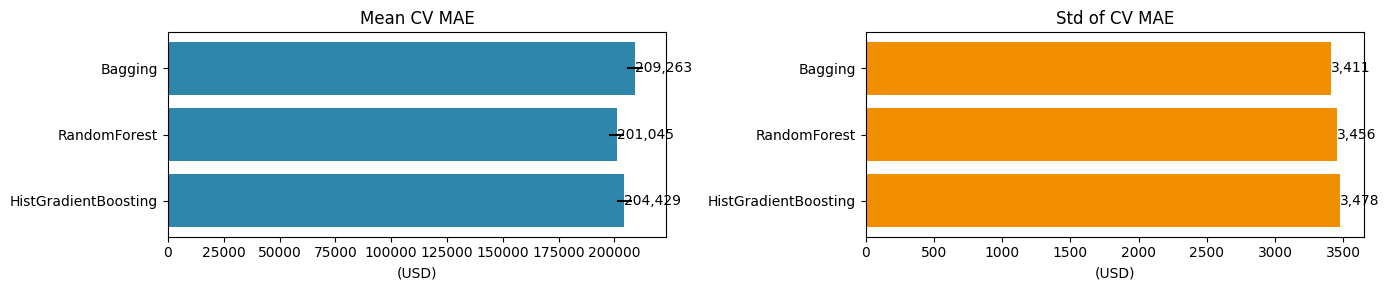

In [8]:
# ============================================================
# VISUALIZATION 1: Bar chart of Mean CV MAE & STD MAE
# ============================================================

# Extract data
models = list(results.keys())
mean_mae = [results[m]["mean_MAE"] for m in models]
std_mae = [results[m]["std_MAE"] for m in models]

# Use a consistent color (close to your screenshot style)
color1 = '#2E86AB'  # seaborn-like muted blue
color2= '#F18F01'

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

# ---- Plot 1: Mean MAE with error bars ----
axes[0].barh(models, mean_mae, xerr=std_mae, color=color1)
axes[0].set_title("Mean CV MAE")
axes[0].set_xlabel("(USD)")

# Add value labels (mean MAE)
for i, v in enumerate(mean_mae):
    axes[0].text(v, i, f"{v:,.0f}", va='center', ha='left')

# ---- Plot 2: Std MAE ----
axes[1].barh(models, std_mae, color=color2)
axes[1].set_title("Std of CV MAE")
axes[1].set_xlabel("(USD)")

# Add value labels (std MAE)
for i, v in enumerate(std_mae):
    axes[1].text(v, i, f"{v:,.0f}", va='center', ha='left')

# Optional: invert y-axis so top model appears at top (like typical ML plots)
axes[0].invert_yaxis()
axes[1].invert_yaxis()

# Layout
plt.tight_layout()
plt.show()

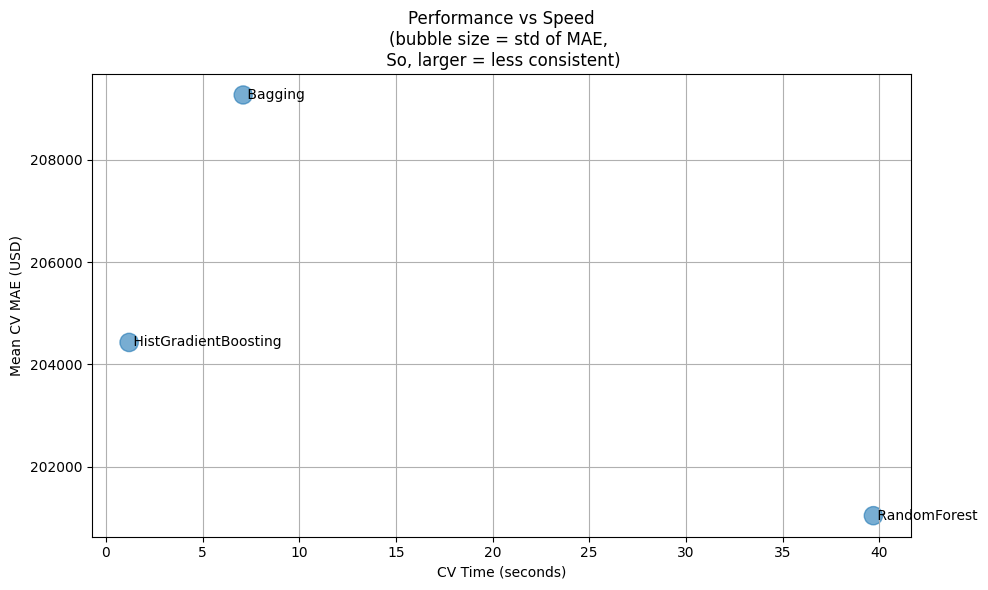

In [9]:
# ============================================================
# VISUALIZATION 2 — Scatter plot: Performance vs Speed
# Helps identify if a slower model is actually worth the 
# extra computation time compared to a faster one
# ============================================================


# Extract data
models = list(results.keys())
mean_mae = [results[m]["mean_MAE"] for m in models]
std_mae = [results[m]["std_MAE"] for m in models]
cv_time = [results[m]["CV Time (s)"] for m in models]

# Scale bubble sizes (adjust multiplier if needed)
sizes = [s * 0.05 for s in std_mae]

# Create plot
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    cv_time,
    mean_mae,
    s=sizes,
    alpha=0.6
)

# Add labels for each point
for i, model in enumerate(models):
    plt.text(
        cv_time[i],
        mean_mae[i],
        f" {model}",
        va='center'
    )

# Titles and labels
plt.xlabel("CV Time (seconds)")
plt.ylabel("Mean CV MAE (USD)")
plt.title("Performance vs Speed\n(bubble size = std of MAE, \n So, larger = less consistent)")

plt.grid(True)
plt.tight_layout()
plt.show()

### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

**Answer**

| Model                  | Mean MAE | Std MAE |
|-----------------------|----------|---------|
| Bagging               | 209,263  | 3,411   |
| Random Forest         | 201,045  | 3,456   |
| HistGradientBoosting  | 204,429  | 3,478   |



**Best performing model:** 
- The **Random Forest** model performed best overall, achieving the **lowest mean MAE (~201,045)**, indicating it provides the most accurate predictions among the three baseline models. This suggests it is better at capturing the underlying patterns in the data compared to Bagging and HistGradientBoosting with <u>default parameters</u>.


**Most stable model:**
- The **Bagging** model had the **lowest standard deviation (~3,411)**, making it the <u>most stable</u> across different cross-validation folds. However, its higher MAE indicates that while it is consistent, it is not as accurate as the other models.


**Overfitting / Underfitting:**
- There are no strong signs of **overfitting**, as all models show relatively low and similar standard deviations, indicating consistent performance across folds. However, there may be **slight underfitting**, especially for Bagging, since its error is noticeably higher. Additionally, the fact that all models are using **default parameters** suggests that **further tuning could improve performance**, particularly for HistGradientBoosting, which is expected to perform better after optimization.


### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [10]:
# Feature Engineering Summary (From Milestone 1 - Part 5)
#
#     1. Log Transformation Features
#       log_sqft = log(1 + calculatedfinishedsquarefeet)
#       log_lotsize = log(1 + lotsizesquarefeet)
#
#     2. Interaction Features
#       sqft_x_bath = calculatedfinishedsquarefeet * bathroomcnt
#       bed_bath_ratio = bedroomcnt / (bathroomcnt + 1)
#


In [11]:
# -----------------------------------------
# Step 1: Add Engineered Features
# -----------------------------------------

# Copy original training data
X_train_fe = X_train.copy()

# -------------------------
# Log Features
# -------------------------
X_train_fe['log_sqft'] = np.log1p(X_train_fe['calculatedfinishedsquarefeet'])
X_train_fe['log_lotsize'] = np.log1p(X_train_fe['lotsizesquarefeet'])

# -------------------------
# Interaction Features
# -------------------------
X_train_fe['sqft_x_bath'] = X_train_fe['calculatedfinishedsquarefeet'] * X_train_fe['bathroomcnt']
X_train_fe['bed_bath_ratio'] = X_train_fe['bedroomcnt'] / (X_train_fe['bathroomcnt'] + 1)


In [12]:
# -------------------------------------
# Step 2: Scale Features
# -------------------------------------
scaler = StandardScaler()

X_train_fe_scaled = scaler.fit_transform(X_train_fe)

In [13]:
# ---------------------------------------------
# Step 3: Re-run Models with CV
# ---------------------------------------------

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

models = {
    "Bagging": BaggingRegressor(random_state=random_state),
    "RandomForest": RandomForestRegressor(random_state=random_state),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=random_state)
}

results_fe = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_fe_scaled,
        y_train,
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_jobs=-1
    )
    
    mae_scores = -scores
    
    results_fe[name] = {
        "mean_MAE": mae_scores.mean(),
        "std_MAE": mae_scores.std()
    }

results_fe

{'Bagging': {'mean_MAE': np.float64(210665.55989865644),
  'std_MAE': np.float64(3464.5295266417456)},
 'RandomForest': {'mean_MAE': np.float64(202275.86038910906),
  'std_MAE': np.float64(3298.87090728044)},
 'HistGradientBoosting': {'mean_MAE': np.float64(205014.8322832639),
  'std_MAE': np.float64(3348.417164251742)}}

In [14]:
# better display of results with engineered features
pd.DataFrame(results_fe)

,Bagging,RandomForest,HistGradientBoosting
mean_MAE,210665.559899,202275.860389,205014.832283
std_MAE,3464.529527,3298.870907,3348.417164


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




**Answer**

**Adding Engineered Features: Before vs After**

| Model                  | Mean MAE (Before) | Mean MAE (After) | Std MAE (Before) | Std MAE (After) |
|-----------------------|------------------|------------------|------------------|-----------------|
| Bagging               | 209,263          | 210,666          | 3,411            | 3,465           |
| Random Forest         | 201,045          | 202,276          | 3,456            | 3,299           |
| HistGradientBoosting  | 204,429          | 205,015          | 3,478            | 3,348           |


**Did any models show notable improvement in performance?**
- The four features added were: (*log_lotsize*,  *sqft_x_bath*, *log_sqft*, and *bed_bath_ratio*), selected based on their F-scores from the Milestone 1 Part 5 analysis. These features were <u>expected to benefit linear models by exposing nonlinear relationships</u>, however since all three models tested here are **tree-based ensembles**, they already discover these patterns internally through their splitting mechanism, making the engineered features redundant rather than additive.

- No, none of the models showed improvement after adding the engineered features. In fact, all three models experienced a **slight increase in MAE**, indicating a small decrease in performance. The changes were not very large, but they were consistent across all models, <u>suggesting that the added features did not provide additional useful information for these models</u>.


**Which new features seemed to help — and in which models?**
- Based on the results, none of the new features clearly improved performance for any of the models. Although the interaction feature **sqft_x_bath** was expected to be helpful (since it had a **high F-score in Milestone 1**), it did not lead to better results here. However, there was a **slight reduction in standard deviation** for Random Forest and HistGradientBoosting, which may suggest that the new features contributed to slightly **more stable predictions**, even if accuracy did not improve.


**Do you have any hypotheses about why a particular feature helped (or didn’t)?**
- One likely explanation is that **tree-based models already capture nonlinear relationships and feature interactions automatically**, so manually adding interaction features like **sqft_x_bath** may introduce redundancy rather than new information. Similarly, log transformations are typically more useful for linear models, while tree-based models are less sensitive to skewed distributions. Additionally, adding multiple derived features may increase **multicollinearity** and introduce noise, which can slightly degrade model performance. Overall, this suggests that feature engineering needs to be aligned with the type of model being used, and not all transformations will lead to improvements.

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [15]:
# ---------------------------------------------
# Part 3: Feature Selection
# Using full feature set = original + engineered
# ---------------------------------------------

# Start from the engineered feature dataset
X_train_fs = X_train_fe.copy()

# Scale full feature set
scaler_fs = StandardScaler()
X_train_fs_scaled = pd.DataFrame(
    scaler_fs.fit_transform(X_train_fs),
    columns=X_train_fs.columns,
    index=X_train_fs.index
)

# Same models
models_fs = {
    "Bagging": BaggingRegressor(random_state=random_state),
    "RandomForest": RandomForestRegressor(random_state=random_state),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=random_state)
}

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

selected_features_by_model = {}
results_selected = {}

for name, model in models_fs.items():
    # Fit model on full feature set
    model.fit(X_train_fs_scaled, y_train)
    
    # Get feature importance
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=X_train_fs_scaled.columns)
    elif name == "Bagging":
        # Average feature importances across bagged estimators if available
        estimator_importances = []
        for est in model.estimators_:
            if hasattr(est, "feature_importances_"):
                estimator_importances.append(est.feature_importances_)
        importances = pd.Series(np.mean(estimator_importances, axis=0), index=X_train_fs_scaled.columns)
    else:
        continue
    
    # Keep features with above-average importance
    threshold = importances.mean()
    selected_features = importances[importances > threshold].index.tolist()
    
    selected_features_by_model[name] = selected_features
    
    # Re-run CV using only selected features
    X_selected = X_train_fs_scaled[selected_features]
    
    scores = cross_val_score(
        model,
        X_selected,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=-1
    )
    
    mae_scores = -scores
    results_selected[name] = {
        "n_features": len(selected_features),
        "selected_features": selected_features,
        "mean_MAE": mae_scores.mean(),
        "std_MAE": mae_scores.std()
    }

pd.DataFrame({
    model: {
        "n_features": results_selected[model]["n_features"],
        "mean_MAE": results_selected[model]["mean_MAE"],
        "std_MAE": results_selected[model]["std_MAE"]
    }
    for model in results_selected
}).T


,n_features,mean_MAE,std_MAE
Bagging,6.0,211196.058384,3724.432487
RandomForest,6.0,203471.169500,3757.182735


In [16]:
for model, feats in selected_features_by_model.items():
    print(f"\n{model} selected features ({len(feats)}):")
    print(feats)


Bagging selected features (6):
['calculatedfinishedsquarefeet', 'latitude', 'longitude', 'yearbuilt', 'log_sqft', 'sqft_x_bath']

RandomForest selected features (6):
['calculatedfinishedsquarefeet', 'latitude', 'longitude', 'yearbuilt', 'log_sqft', 'sqft_x_bath']


In [17]:
# ---------------------------------------------
# HistGradientBoosting feature selection
# ---------------------------------------------
subset_sizes = [5, 6, 8, 10, 12, X_train_fs_scaled.shape[1]]

best_mae = float("inf")
best_std = None
best_features_hgb = None

for k in subset_sizes:
    selector = SelectKBest(score_func=f_regression, k=k)
    X_selected = selector.fit_transform(X_train_fs_scaled, y_train)

    selected_features = X_train_fs_scaled.columns[selector.get_support()].tolist()

    model = HistGradientBoostingRegressor(random_state=random_state)

    scores = cross_val_score(
        model,
        X_selected,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=-1
    )

    mae_scores = -scores
    mean_mae = mae_scores.mean()
    std_mae = mae_scores.std()

    if mean_mae < best_mae:
        best_mae = mean_mae
        best_std = std_mae
        best_features_hgb = selected_features

print("Best HistGradientBoosting features:")
print(best_features_hgb)
print("Mean MAE:", best_mae)
print("Std MAE:", best_std)

Best HistGradientBoosting features:
['airconditioningtypeid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'garagecarcnt', 'garagetotalsqft', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcounty', 'roomcnt', 'unitcnt', 'yearbuilt', 'log_sqft', 'log_lotsize', 'sqft_x_bath', 'bed_bath_ratio']
Mean MAE: 205014.8322832639
Std MAE: 3348.417164251742


In [18]:
part3_results = pd.DataFrame({
    "Bagging": {
        "n_features": 6,
        "mean_MAE": 211196.058384,
        "std_MAE": 3724.432487
    },
    "RandomForest": {
        "n_features": 6,
        "mean_MAE": 203471.169500,
        "std_MAE": 3757.182735
    },
    "HistGradientBoosting": {
        "n_features": len(best_features_hgb),
        "mean_MAE": best_mae,
        "std_MAE": best_std
    }
}).T

part3_results

,n_features,mean_MAE,std_MAE
Bagging,6.0,211196.058384,3724.432487
RandomForest,6.0,203471.169500,3757.182735
HistGradientBoosting,21.0,205014.832283,3348.417164


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


**Answer**

**Feature Selection Results**

| Model                  | Selected Features | Mean MAE   | Std MAE | Selected Feature Names |
|------------------------|------------------|------------|---------| ---------------------------------------------------------------------------------------------------|
| Bagging               | 6                | 211,196.06 | 3,724.43 |'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'yearbuilt', 'log_sqft', 'sqft_x_bath'|
| Random Forest         | 6                | 203,471.17 | 3,757.18 |'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'yearbuilt', 'log_sqft', 'sqft_x_bath'|
| HistGradientBoosting  | 21               | 205,014.83 | 3,348.42 |All features = 17 original features (cleaned dataset from Part3 of milestone 1) + 4 Engineered Features|


**Did performance improve for any models after reducing the number of features?**

- No, feature selection did not improve performance for any of the models. Both **Bagging** and **Random Forest** had <u>slightly higher MAE after reducing the number of features</u>, and **HistGradientBoosting** performed best when <u>all 21 features were kept</u>. 
- This suggests that reducing the feature set did not help and may have removed information that was still useful for prediction.


**Which features were consistently retained across models?**

- The features consistently retained across Bagging and Random Forest were:
    - *calculatedfinishedsquarefeet*
    - *latitude*
    - *longitude*
    - *yearbuilt*
    - *log_sqft*
    - *sqft_x_bath*

- These make sense as important predictors because they capture **home size**, **location**, **age**, and an interaction between **square footage** and **number of bathrooms**.


**Were any of your newly engineered features selected as important?**

- Yes, two of the newly engineered features were selected as important by both Bagging and Random Forest:
    - *log_sqft*
    - *sqft_x_bath*

- This suggests that these engineered features did capture some useful information. However, even though they were retained, the reduced feature subsets still did not improve model accuracy overall.

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [19]:
# -----------------------------------------------------------------------
# Random Forest: 
# Using the original scaled features (without the engineered features) of the cleaned dataset at part3 in milestone 1 (the cleaned dataset that milestone 2 starts with)
# -----------------------------------------------------------------------

X_rf_scaled = X_train_scaled.copy() # only original scaled features of the cleaned dataset in milestone 1


# ---------------------------------------------------------------------------
# Bagging and HistGradientBoosting models:
# Feature subsets (based on feature selection done in Part3) 
# ---------------------------------------------------------------------------

features_bag = [
    'calculatedfinishedsquarefeet',
    'latitude',
    'longitude',
    'yearbuilt',
    'log_sqft',
    'sqft_x_bath'
]

features_hgb = [
    'airconditioningtypeid', 'bathroomcnt', 'bedroomcnt',
    'buildingqualitytypeid', 'calculatedfinishedsquarefeet',
    'garagecarcnt', 'garagetotalsqft', 'heatingorsystemtypeid',
    'latitude', 'longitude', 'lotsizesquarefeet',
    'propertylandusetypeid', 'propertyzoningdesc',
    'regionidcounty', 'roomcnt', 'unitcnt',
    'yearbuilt', 'log_sqft', 'log_lotsize',
    'sqft_x_bath', 'bed_bath_ratio'
]

# Create subset datasets from the dataset that holds raw features + engineered features 
X_bag = X_train_fe[features_bag].copy()
X_hgb = X_train_fe[features_hgb].copy()



# Scale for Random Forest & Bagging training set
scaler_bag = StandardScaler()
X_bag_scaled = scaler_bag.fit_transform(X_bag)

# Scale for HistGradientBoosting
scaler_hgb = StandardScaler()
X_hgb_scaled = scaler_hgb.fit_transform(X_hgb)

In [20]:
# -----------------------------------------------------------
# sweep_parameters Function (with Plotting)
# ----------------------------------------------------------


def sweep_parameters(model_class, param_grid, X, y, cv=5, random_state=42):
    """
    Perform parameter sweep and plot results for each hyperparameter.
    """
    
    sweep_results = {}
    
    for param_name, values in param_grid.items():
        print(f"\nSweeping parameter: {param_name}")
        
        param_results = []
        param_values = []
        mae_values = []
        
        for val in values:
            params = {param_name: val, "random_state": random_state}
            model = model_class(**params)
            
            scores = cross_val_score(
                model,
                X,
                y,
                scoring='neg_mean_absolute_error',
                cv=cv,
                n_jobs=-1
            )
            
            mean_mae = -scores.mean()
            std_mae = scores.std()
            
            param_results.append({
                "value": val,
                "mean_MAE": mean_mae,
                "std": std_mae
            })
            
            param_values.append(val)
            mae_values.append(mean_mae)
            
            print(f"{param_name}={val} → MAE={mean_mae:.2f}")
        
        # Save results
        sweep_results[param_name] = param_results
        
        # =============================
        # Plotting
        # =============================
        plt.figure()
        plt.plot(param_values, mae_values, marker='o')
        plt.xlabel(param_name)
        plt.ylabel("Mean MAE")
        plt.title(f"Sweep Results: {param_name}")
        plt.grid(True)
        plt.show()
    
    return sweep_results


**We’ll structure each model with:**

- **Step 1: Parameter Sweep (exploration)**
- **Step 2: Hyperparameter Tuning (refinement)**


Sweeping parameter: n_estimators
n_estimators=50 → MAE=201186.28
n_estimators=100 → MAE=200416.44
n_estimators=200 → MAE=200052.23


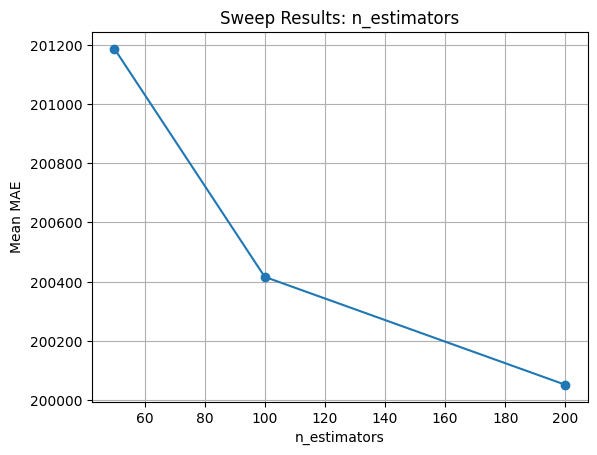


Sweeping parameter: max_depth
max_depth=None → MAE=200416.44
max_depth=10 → MAE=207536.09
max_depth=20 → MAE=199457.15


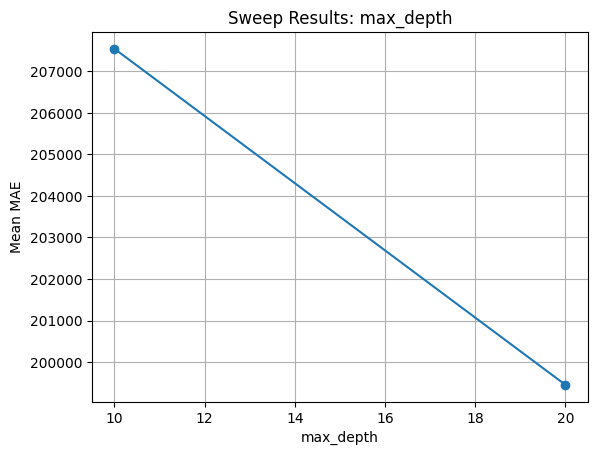


Sweeping parameter: min_samples_split
min_samples_split=2 → MAE=200416.44
min_samples_split=5 → MAE=200264.04
min_samples_split=10 → MAE=200189.12


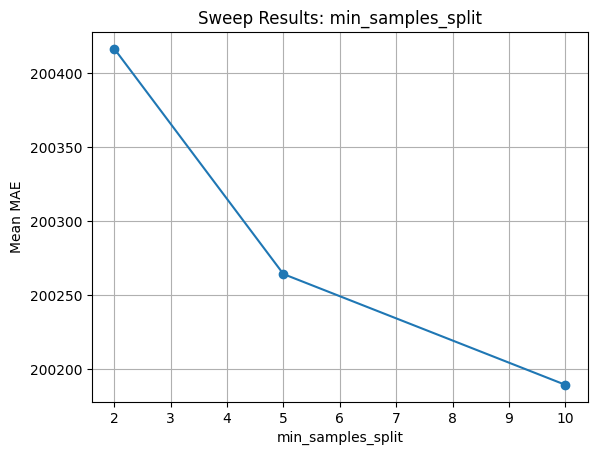

{'n_estimators': [{'value': 50,
   'mean_MAE': np.float64(201186.27750220674),
   'std': np.float64(4523.987627797126)},
  {'value': 100,
   'mean_MAE': np.float64(200416.4403416771),
   'std': np.float64(4563.607453247616)},
  {'value': 200,
   'mean_MAE': np.float64(200052.2290547044),
   'std': np.float64(4534.511881697739)}],
 'max_depth': [{'value': None,
   'mean_MAE': np.float64(200416.4403416771),
   'std': np.float64(4563.607453247616)},
  {'value': 10,
   'mean_MAE': np.float64(207536.09055109762),
   'std': np.float64(4842.233392630187)},
  {'value': 20,
   'mean_MAE': np.float64(199457.14802534887),
   'std': np.float64(4567.760645888939)}],
 'min_samples_split': [{'value': 2,
   'mean_MAE': np.float64(200416.4403416771),
   'std': np.float64(4563.607453247616)},
  {'value': 5,
   'mean_MAE': np.float64(200264.0370600485),
   'std': np.float64(4577.879645693116)},
  {'value': 10,
   'mean_MAE': np.float64(200189.11755681777),
   'std': np.float64(4597.275434517704)}]}

In [21]:
# -------------------------------------------
# Model 1: Random Forest | STEP 1 : Parameter Sweep
# -------------------------------------------

rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

rf_sweep_results = sweep_parameters(
    RandomForestRegressor,
    rf_param_grid,
    X_rf_scaled,
    y_train,
    cv=5,
    random_state=random_state
)

rf_sweep_results

In [22]:
# ------------------------------------------------------------------
# Model 1: Random Forest | Step 2: RandomizedSearchCV (Refined Search)
# ------------------------------------------------------------------

from scipy.stats import randint

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

rf_params = {
    "n_estimators": randint(100, 300),
    "max_depth": randint(10, 20),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 20),
    "max_features": ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=random_state),
    rf_params,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=cv,
    random_state=random_state,
    n_jobs=-1,
    verbose=3
)


rf_search.fit(X_rf_scaled, y_train)

best_rf = rf_search.best_estimator_

print("Best RF Params:", rf_search.best_params_)

Fitting 25 folds for each of 50 candidates, totalling 1250 fits
Best RF Params: {'max_depth': 19, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 191}



Sweeping parameter: n_estimators
n_estimators=10 → MAE=211507.04
n_estimators=50 → MAE=204222.13
n_estimators=100 → MAE=203151.29


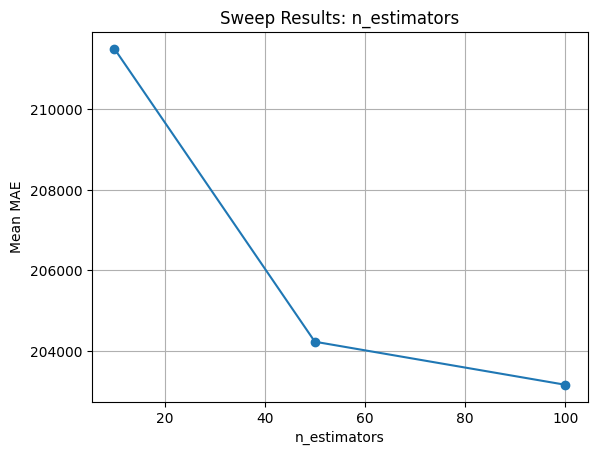


Sweeping parameter: max_samples
max_samples=0.5 → MAE=211671.02
max_samples=0.8 → MAE=210979.80
max_samples=1.0 → MAE=211507.04


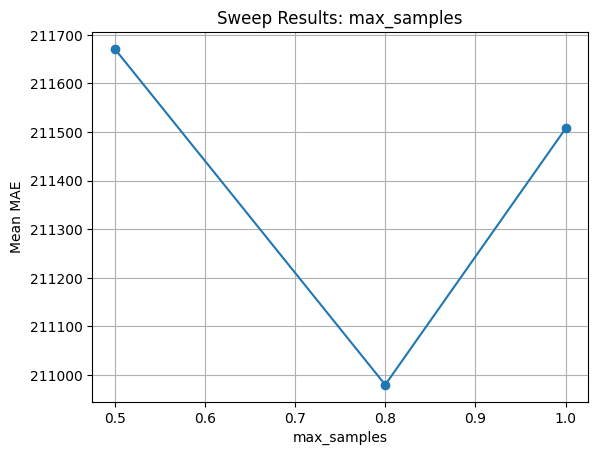


Sweeping parameter: max_features
max_features=0.5 → MAE=228890.46
max_features=0.8 → MAE=223461.69
max_features=1.0 → MAE=211507.04


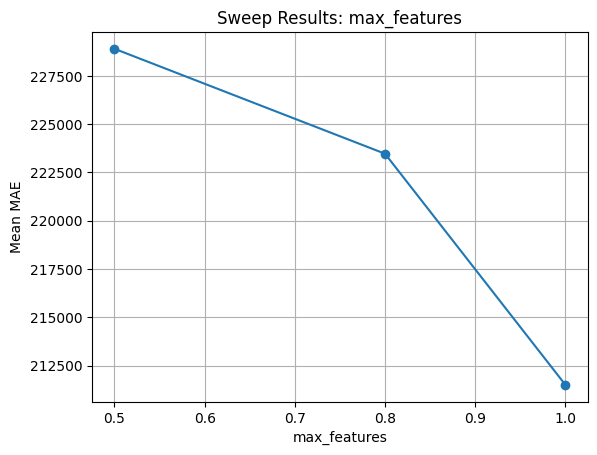

In [23]:
# -------------------------------------------
# Model 2: Bagging | STEP 1 : Parameter Sweep
# -------------------------------------------

bag_param_grid = {
    "n_estimators": [10, 50, 100],
    "max_samples": [0.5, 0.8, 1.0],
    "max_features": [0.5, 0.8, 1.0]
}

bag_sweep_results = sweep_parameters(
    BaggingRegressor,
    bag_param_grid,
    X_bag_scaled,
    y_train,
    random_state=random_state
)

In [24]:
# ----------------------------------------------
# Model 2: Bagging | STEP 2 : GridSearchCV
# ----------------------------------------------

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

bag_grid = {
    "n_estimators": [30, 50, 100],
    "max_samples": [0.6, 0.8],
    "max_features": [0.6, 0.8, 1.0]
}

bag_grid_search = GridSearchCV(
    BaggingRegressor(random_state=random_state),
    bag_grid,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1
)

bag_grid_search.fit(X_bag_scaled, y_train)

best_bag = bag_grid_search.best_estimator_

print("Best Bagging Params:", bag_grid_search.best_params_)

Best Bagging Params: {'max_features': 1.0, 'max_samples': 0.6, 'n_estimators': 100}



Sweeping parameter: learning_rate
learning_rate=0.01 → MAE=238511.10
learning_rate=0.05 → MAE=205580.57
learning_rate=0.1 → MAE=204146.85


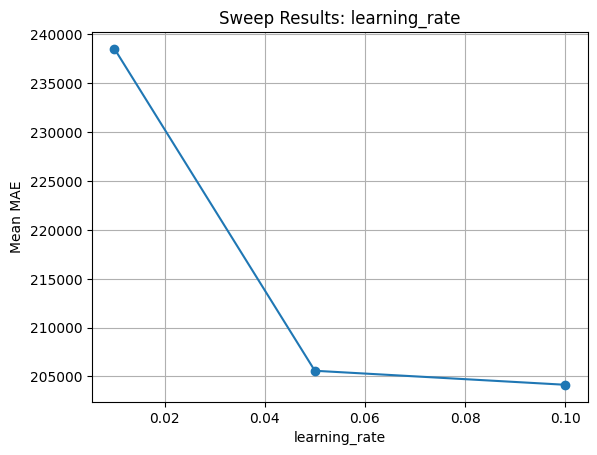


Sweeping parameter: max_depth
max_depth=None → MAE=204146.85
max_depth=5 → MAE=207074.70
max_depth=10 → MAE=203851.25


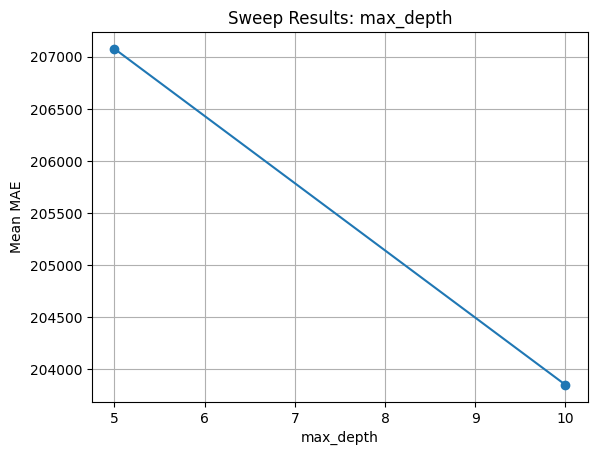


Sweeping parameter: max_iter
max_iter=100 → MAE=204146.85
max_iter=200 → MAE=204031.09


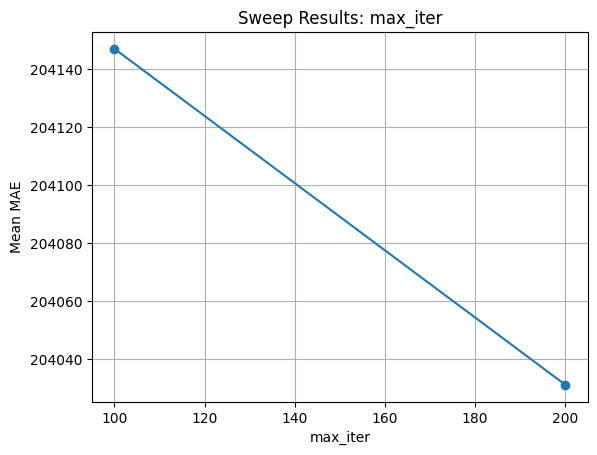

In [25]:
# --------------------------------------------------------------
# Model 3: HistGradientBoosting | STEP 1 : Parameter Sweep
# ---------------------------------------------------------------

hgb_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [None, 5, 10],
    "max_iter": [100, 200]
}

hgb_sweep_results = sweep_parameters(
    HistGradientBoostingRegressor,
    hgb_param_grid,
    X_hgb_scaled,
    y_train,
    random_state=random_state
)

In [26]:
# --------------------------------------------------------------
# Model 3: HistGradientBoosting | STEP 2 : Optuna
# ---------------------------------------------------------------

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.12),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "max_iter": trial.suggest_int("max_iter", 100, 300),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 20, 80),
    }
    
    model = HistGradientBoostingRegressor(**params, random_state=random_state)
    
    score = cross_val_score(
        model,
        X_hgb_scaled,
        y_train,
        scoring='neg_mean_absolute_error',
        cv=cv
    ).mean()
    
    return -score

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=150)

best_hgb = HistGradientBoostingRegressor(
    **study.best_params,
    random_state=random_state
)

[I 2026-04-11 19:38:41,696] A new study created in memory with name: no-name-60dafde4-6599-4571-a870-a3433044077c
[I 2026-04-11 19:39:10,072] Trial 0 finished with value: 204132.07544016416 and parameters: {'learning_rate': 0.06100248175231869, 'max_depth': 9, 'max_iter': 146, 'min_samples_leaf': 66}. Best is trial 0 with value: 204132.07544016416.
[I 2026-04-11 19:39:18,808] Trial 1 finished with value: 204129.0838371379 and parameters: {'learning_rate': 0.078343738102653, 'max_depth': 9, 'max_iter': 127, 'min_samples_leaf': 67}. Best is trial 1 with value: 204129.0838371379.
[I 2026-04-11 19:39:29,193] Trial 2 finished with value: 204444.84669747148 and parameters: {'learning_rate': 0.07727387463408672, 'max_depth': 9, 'max_iter': 291, 'min_samples_leaf': 75}. Best is trial 1 with value: 204129.0838371379.
[I 2026-04-11 19:39:41,782] Trial 3 finished with value: 205056.70733057454 and parameters: {'learning_rate': 0.038750840859218955, 'max_depth': 8, 'max_iter': 242, 'min_samples_le

In [28]:
# ------------------------------
# Final Evaluation
# ------------------------------

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

final_results_subset = {}

models = {
    "RF_originalFeatureSet": best_rf,
    "Bagging_subset": best_bag,
    "HGB_allFeatures_original&Engineered": best_hgb
}

data_map = {
    "RF_originalFeatureSet": X_rf_scaled,
    "Bagging_subset": X_bag_scaled,
    "HGB_allFeatures_original&Engineered": X_hgb_scaled
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        data_map[name],
        y_train,
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_jobs=-1
    )
    
    mae = -scores
    
    final_results_subset[name] = {
        "mean_MAE": mae.mean(),
        "std_MAE": mae.std()
    }

final_results_subset

{'RF_originalFeatureSet': {'mean_MAE': np.float64(198962.45717910372),
  'std_MAE': np.float64(3480.951547574832)},
 'Bagging_subset': {'mean_MAE': np.float64(202453.05702922653),
  'std_MAE': np.float64(3786.9291470131175)},
 'HGB_allFeatures_original&Engineered': {'mean_MAE': np.float64(203319.63952399284),
  'std_MAE': np.float64(3783.128965186525)}}

In [29]:
# better display
pd.DataFrame(final_results_subset)

,RF_originalFeatureSet,Bagging_subset,HGB_allFeatures_original&Engineered
mean_MAE,198962.457179,202453.057029,203319.639524
std_MAE,3480.951548,3786.929147,3783.128965


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


**Answer**

**What was your tuning strategy for each model? Why did you choose those hyperparameters?**

- A **two-step** tuning strategy was applied to all models. 
- **First**, a **parameter sweep** was performed to understand how individual hyperparameters affect model performance and to identify reasonable value ranges. 
- **Second**, based on these parameter sweeping observations, **different tuning methods** were applied to each model:
    - For **Random Forest**, **RandomizedSearchCV was used** with parameter distributions (e.g., randint) to efficiently explore a larger search space for parameters such as the *number of trees*, *tree depth*, and *split criteria*. 
    - For **Bagging**, **GridSearchCV** was used since the parameter space was smaller and more manageable, allowing for a systematic evaluation of combinations like *n_estimators*, *max_samples*, and *max_features*. 
    - For **HistGradientBoosting**, **Optuna** was used because it enables adaptive and continuous optimization of parameters such as *learning rate*, *tree depth*, and *number of iterations*. 

- The **selected hyperparameters** for each model were chosen based on their ability to **minimize MAE** while maintaining stable performance across **repeated cross-validation**, but also because they directly control key aspects of model behavior. 
    - For example:
        - parameters like *n_estimators* and *max_iter* affect the model capacity and learning strength
        - while parameters such as *max_depth*, *min_samples_split*, and *min_samples_leaf* control model complexity and help prevent overfitting. 
        - In addition, parameters like *learning_rate* in boosting models determine how quickly the model learns, which impacts both accuracy and stability.

    - These hyperparameters were specifically targeted because they influence the bias–variance trade-off, which is critical for achieving good generalization. By tuning them, we aimed to find a balance where the model is complex enough to capture patterns in the data but not so complex that it overfits. 
    - The final selections were based on combinations that consistently produced low MAE and low variability across folds, indicating both strong predictive performance and reliable behavior on different data splits.


**Did you find that certain types of preprocessing or feature engineering worked better with specific models?**

- Yes, the results suggest that different models respond differently to preprocessing and feature engineering.
- The **Random Forest** performed best when trained only on the **original features, without additional engineered features,** suggesting that it can effectively capture **nonlinear** relationships and interactions on its own.
- The **Bagging** model performed well using a **smaller subset** of key features, mainly related to *property size*, *location*, and *year built*. This indicates that this model is effective at capturing important patterns without requiring many additional features. 
- On the other hand, **HistGradientBoosting** used a **larger feature set**, including engineered features like *log transformations* and *interaction terms*, but this did not result in significantly better performance. 
- Overall, feature engineering and feature selection did not consistently improve model accuracy, suggesting that these models already capture nonlinear relationships and interactions internally. 
- Among all models, **Random Forest** achieved the best final MAE (**198,962**), along with the lowest variability (std=**3481**), showing both higher accuracy and better stability, while the other models performed slightly worse but still relatively close.

### Feature Sets Used During Model Hyperparameters Tuning

| Model                     | Feature Set Used During Tuning |
|--------------------------|------------------------------|
| Random Forest            | 17 Original features only (from cleaned dataset) |
| Bagging                  | Selected 6 Features (including 2 engineered features): <br> [*calculatedfinishedsquarefeet, latitude, longitude, yearbuilt, log_sqft, sqft_x_bath*] |
| HistGradientBoosting     | Extended feature set including 17 original features + 4 engineered features|

**Model Comparison: Baseline vs Tuned**
- *All models evaluated using Repeated CV (5 folds × 5 repeats) | MAE in USD*



| Model               | Baseline MAE | Baseline Std | Tuned MAE | Tuned Std | Improvement ($) | Improvement (%) | Best Params |
|--------------------|-------------:|-------------:|----------:|----------:|----------------:|----------------:|-------------|
| Random Forest      | $201,045     | $3,456       | $198,962  | $3,481    | $2,083          | 1.04%           | n_estimators=191, max_depth=19, max_features='sqrt', min_samples_leaf=2, min_samples_split=5   |
| Bagging            | $209,263     | $3,411       | $202,453  | $3,787    | $6,810          | 3.3%            | n_estimators=100, max_samples=0.6, max_features=1.0 |
| HistGradientBoosting | $204,429   | $3,478       | $203,320  | $3,783    | $1,109          | 0.5%            | learning_rate=0.073, max_depth=9, max_iter=269, min_samples_leaf=43 |



- **Bagging** improved the most:
    - $6,810 reduction in MAE after tuning, going from worst to second best of the three
- **Random Forest** got slightly better after tuning:
    - $2,083 decrease in MAE, using the original features of the cleaned dataset
- **HistGradientBoosting** improved modestly 
    - $1,109 reduction, suggesting it was already performing near its optimal at default parameters


**Final ranking after tuning (by mean MAE)**
- 1. Random Forest ($198,962), which was also the best at baseline
- 2. Bagging ($202,453), 
- 3. HistGradientBoosting ($203,320), 



**Best hyperparameters found**
- Random Forest: 
    - n_estimators=191
    - max_depth=19
    - max_features='sqrt'
    - min_samples_leaf=2
    - min_samples_split=5
- Bagging: 
    - n_estimators=100
    - max_samples=0.6
    - max_features=1.0
- HistGradientBoosting: 
    - learning_rate=0.073
    - max_depth=9
    - max_iter=269
    - min_samples_leaf=43


### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [23]:
# Training/test data (original features from the cleaned dataset that this milestone started with)
X_train_final = X_train.copy()
X_test_final = X_test.copy()

# Scaling
scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_test_final_scaled = scaler.transform(X_test_final)


In [24]:
# Final Model (Best Parameters from RandomizedSearchCV)
final_model = best_rf

In [32]:
# Cross-Validation Performance

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

cv_scores = cross_val_score(
    final_model,
    X_train_final_scaled,
    y_train,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1
)

cv_mae = -cv_scores

print("Final Model (Random Forest) CV Results:")
print("Mean MAE:", cv_mae.mean())
print("Std MAE:", cv_mae.std())

Final Model (Random Forest) CV Results:
Mean MAE: 198962.45717910372
Std MAE: 3480.951547574832


In [33]:
from sklearn.metrics import mean_absolute_error

# Train on full training data
final_model.fit(X_train_final_scaled, y_train)

# Predict on test set
y_pred = final_model.predict(X_test_final_scaled)

# Compute MAE
test_mae = mean_absolute_error(y_test, y_pred)

print("\nTest MAE:", test_mae)


Test MAE: 194860.9679128546


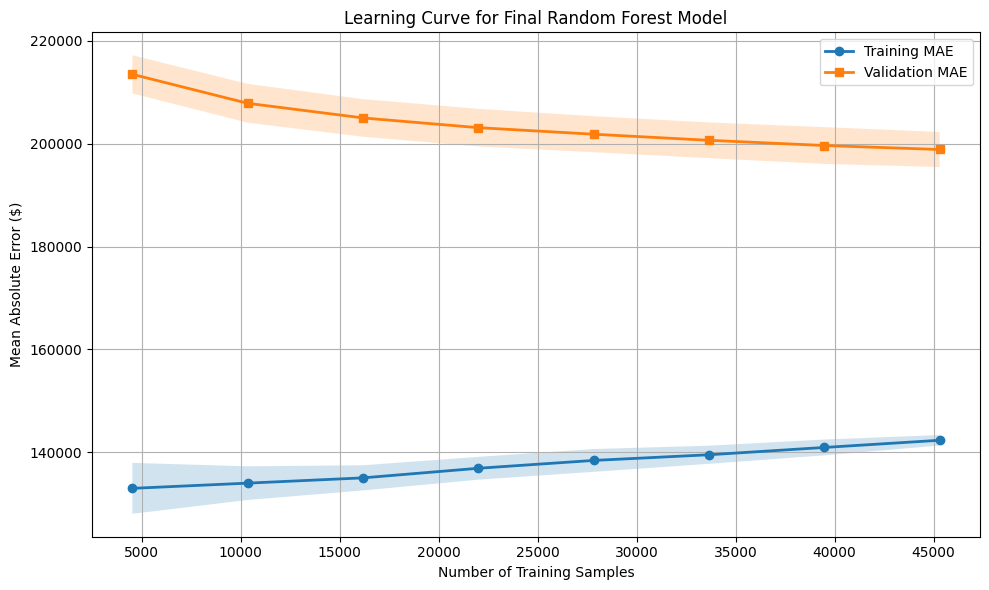

In [25]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

# Learning curve settings
train_sizes = np.linspace(0.1, 1.0, 8)

train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=final_model,
    X=X_train_final_scaled,
    y=y_train,
    train_sizes=train_sizes,
    cv=cv,  # uses the same RepeatedKFold object already defined above
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    shuffle=True,
    random_state=random_state
)

# Convert negative MAE to positive MAE
train_mae = -train_scores
val_mae = -val_scores

# Mean and std across folds
train_mae_mean = train_mae.mean(axis=1)
train_mae_std = train_mae.std(axis=1)

val_mae_mean = val_mae.mean(axis=1)
val_mae_std = val_mae.std(axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_mae_mean, marker='o', linewidth=2, label='Training MAE')
plt.plot(train_sizes_abs, val_mae_mean, marker='s', linewidth=2, label='Validation MAE')

plt.fill_between(
    train_sizes_abs,
    train_mae_mean - train_mae_std,
    train_mae_mean + train_mae_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes_abs,
    val_mae_mean - val_mae_std,
    val_mae_mean + val_mae_std,
    alpha=0.2
)

plt.title('Learning Curve for Final Random Forest Model')
plt.xlabel('Number of Training Samples')
plt.ylabel('Mean Absolute Error ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

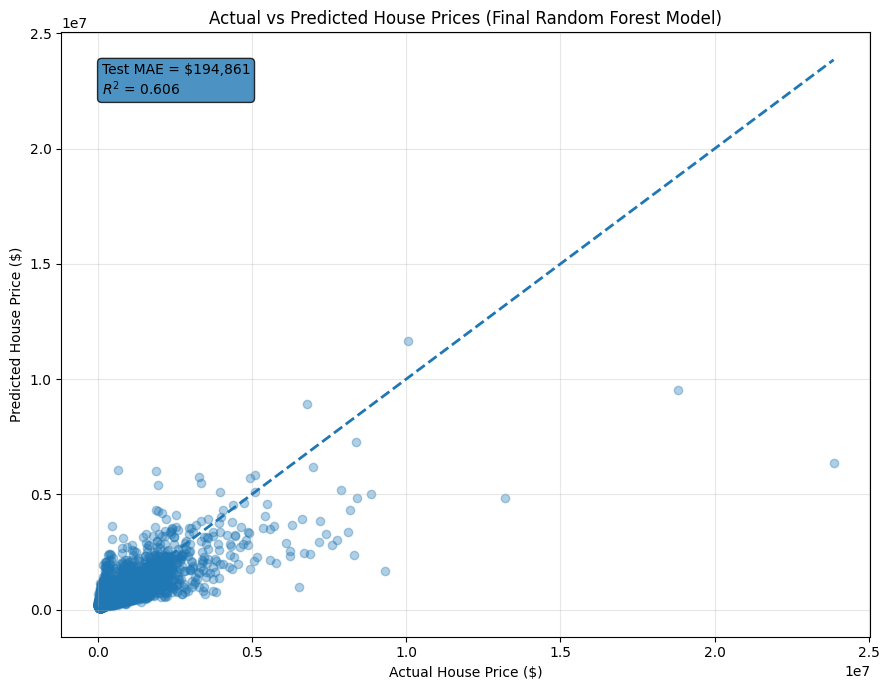

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# Generate predictions on the test set
y_test_pred = final_model.predict(X_test_final_scaled)

# Optional summary metrics for reference
test_mae_plot = mean_absolute_error(y_test, y_test_pred)
test_r2_plot = r2_score(y_test, y_test_pred)

# Line for perfect predictions
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

# Plot
plt.figure(figsize=(9, 7))
plt.scatter(y_test, y_test_pred, alpha=0.35)
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=2)

plt.title('Actual vs Predicted House Prices (Final Random Forest Model)')
plt.xlabel('Actual House Price ($)')
plt.ylabel('Predicted House Price ($)')
plt.grid(True, alpha=0.3)

# Add metrics as text on the figure
plt.text(
    0.05, 0.95,
    f'Test MAE = ${test_mae_plot:,.0f}\n$R^2$ = {test_r2_plot:.3f}',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', alpha=0.8)
)

plt.tight_layout()
plt.show()

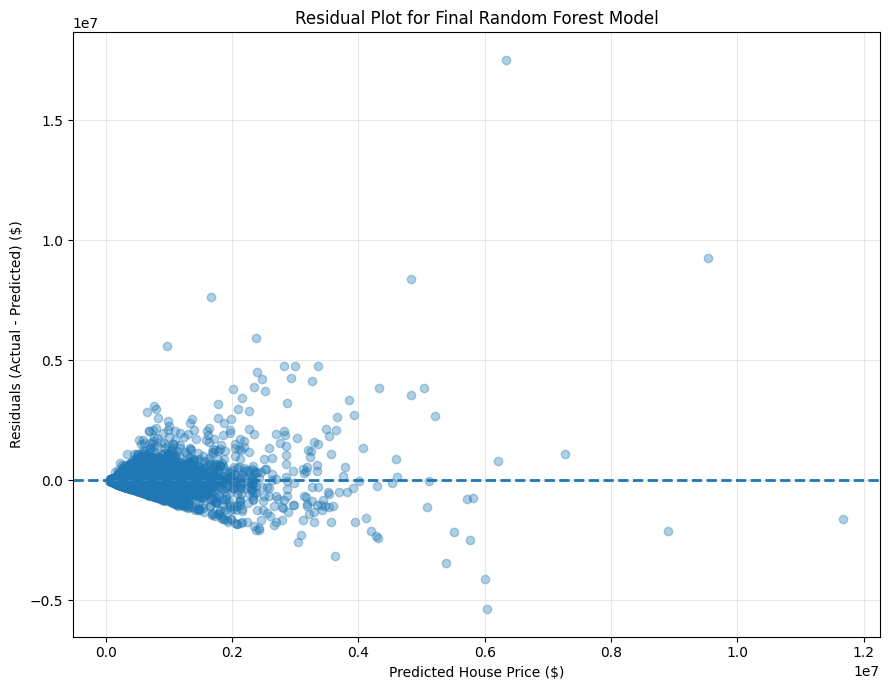

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Predictions on test set
y_test_pred = final_model.predict(X_test_final_scaled)

# Residuals
residuals = y_test - y_test_pred

# Plot
plt.figure(figsize=(9, 7))
plt.scatter(y_test_pred, residuals, alpha=0.35)
plt.axhline(y=0, linestyle='--', linewidth=2)

plt.title('Residual Plot for Final Random Forest Model')
plt.xlabel('Predicted House Price ($)')
plt.ylabel('Residuals (Actual - Predicted) ($)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

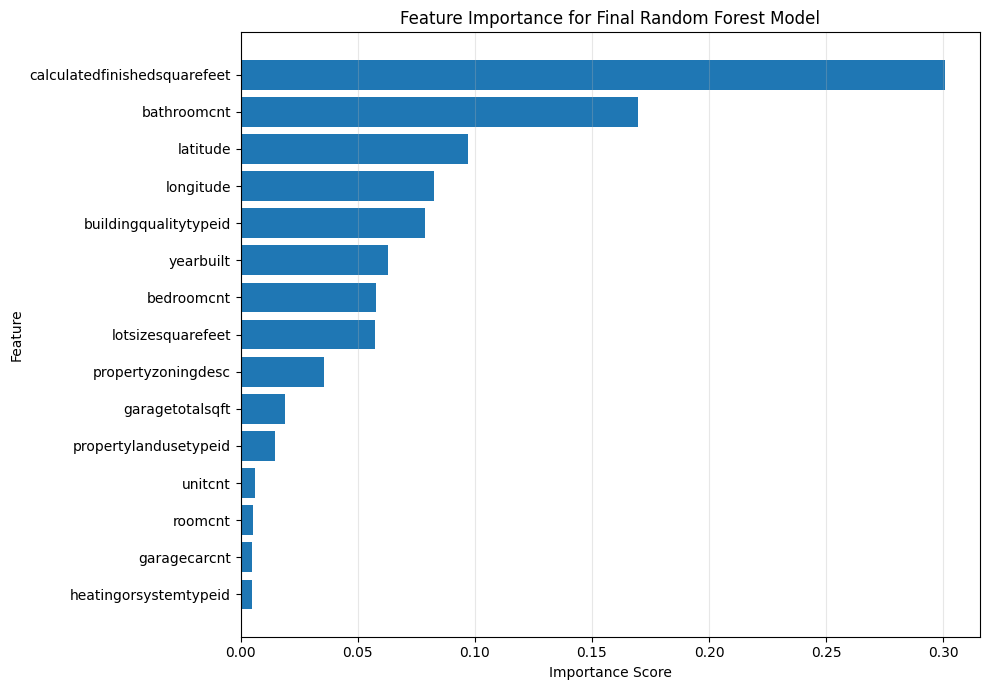

,Feature,Importance
4,calculatedfinishedsquarefeet,0.300717
1,bathroomcnt,0.169687
8,latitude,0.097099
9,longitude,0.082585
3,buildingqualitytypeid,0.078892
16,yearbuilt,0.062851
2,bedroomcnt,0.057682
10,lotsizesquarefeet,0.057427
12,propertyzoningdesc,0.035342
6,garagetotalsqft,0.019008


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the final Random Forest model
importances = final_model.feature_importances_

# Create a dataframe for easier sorting and plotting
feature_importance_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top features
top_n = 15

plt.figure(figsize=(10, 7))
plt.barh(
    feature_importance_df['Feature'].head(top_n)[::-1],
    feature_importance_df['Importance'].head(top_n)[::-1]
)

plt.title('Feature Importance for Final Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: display the full ranked table
feature_importance_df.head(15)

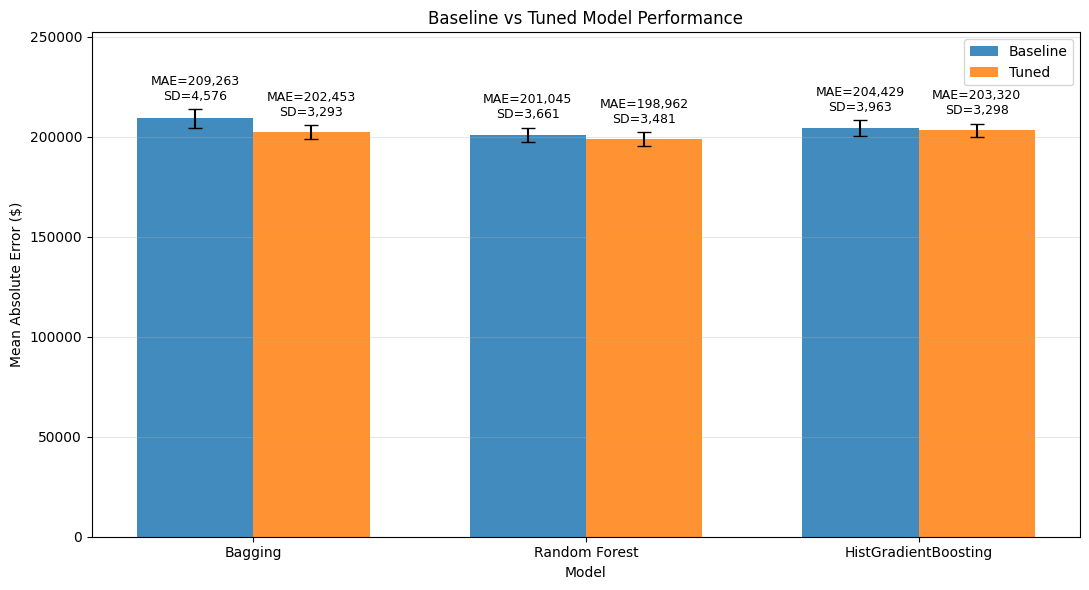

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Replace with the exact values from your notebook if needed
models = ['Bagging', 'Random Forest', 'HistGradientBoosting']

baseline_mae = [209263, 201045, 204429]
baseline_std = [4576, 3661, 3963]

tuned_mae = [202453, 198962, 203320]
tuned_std = [3293, 3481, 3298]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(11, 6))

bars1 = plt.bar(
    x - width/2,
    baseline_mae,
    width,
    yerr=baseline_std,
    capsize=5,
    label='Baseline',
    alpha=0.85
)

bars2 = plt.bar(
    x + width/2,
    tuned_mae,
    width,
    yerr=tuned_std,
    capsize=5,
    label='Tuned',
    alpha=0.85
)

plt.title('Baseline vs Tuned Model Performance')
plt.xlabel('Model')
plt.ylabel('Mean Absolute Error ($)')
plt.xticks(x, models)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

# Increase upper y-limit so bars appear shorter and labels stay inside plot
y_max = max(
    max(np.array(baseline_mae) + np.array(baseline_std)),
    max(np.array(tuned_mae) + np.array(tuned_std))
)
plt.ylim(0, y_max * 1.18)

# Add MAE and SD labels above each bar, but still inside the plot
offset = y_max * 0.015

for bar, mae, std in zip(bars1, baseline_mae, baseline_std):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        mae + std + offset,
        f'MAE={mae:,.0f}\nSD={std:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

for bar, mae, std in zip(bars2, tuned_mae, tuned_std):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        mae + std + offset,
        f'MAE={mae:,.0f}\nSD={std:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Final Model Results**

- Cross-Validation MAE:
  - Mean MAE: 198,962.46
  - Std MAE: 3,480.95

- Test Set MAE:
  - MAE: 194,860.97

### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

**Answer**

**1. Model Selection**

- The final model selected was the **Random Forest Regressor** because it achieved the **lowest mean MAE** during cross-validation (**198,962.46**) among the three tuned models. Since the main objective of the project is to minimize prediction error, this made Random Forest the most suitable choice.

- The decision was mainly based on **cross-validation performance, stability, and generalization**. The model had the **lowest standard deviation** (**3,480.95**), indicating more consistent performance across folds. In addition, the **test MAE (194,860.97)** was slightly lower than the cross-validation MAE, which suggests that the model **generalizes well and does not suffer from overfitting**.

- There were some trade-offs in the selection process. While models like **Bagging** and **HistGradientBoosting** are also strong ensemble methods, they did not outperform Random Forest after tuning. An important observation was that **Random Forest performed best using the original feature set**, while the other models relied on engineered features without achieving better results. In terms of **interpretability**, all models are ensemble-based and not easily interpretable, so the final decision was driven mainly by **predictive performance and stability** rather than simplicity.



**2. Revisiting an Early Decision**

- One important feature engineering decision made in Milestone 1 was the creation of **interaction and log-transformed features**, such as *sqft_x_bath* and *log_sqft*. At the time, the goal was to **capture nonlinear relationships and reduce skewness** in features like *property size*, which showed strong right-skewed distributions during EDA. Based on the correlation and F-statistic analysis, these engineered features appeared promising, especially *sqft_x_bath*, which had a high predictive signal.

- However, after evaluating the full modeling pipeline in Milestone 2, these features **did not improve model performance** when added to the dataset. In Part 2, all three models showed a **slight increase in MAE after including the engineered features**, indicating that they did not add useful information. This is likely because the models used (<u>tree-based ensembles</u>) already **capture nonlinear relationships and interactions automatically**, making manual feature engineering somewhat redundant.

- As a result, the final model (**Random Forest**) was trained using the **original feature set**, without relying on engineered features. While some engineered features were still used in other models, they did not lead to better overall performance. This decision was supported by validation results, which showed that **simpler feature sets performed better for Random Forest**. Overall, this highlighted that feature engineering should be **aligned with the model type**, and that more complex features do not always lead to improved results.




**3. Lessons Learned**

- Through this end-to-end workflow, one key insight was that **not all preprocessing or feature engineering steps improve model performance**, especially when using **tree-based ensemble models**. Initially, we expected that adding engineered features and reducing the feature set would lead to better results, but the experiments showed that models like **Random Forest** and **Bagging** are already effective at capturing **nonlinear relationships and feature interactions**. Another important takeaway was the value of **systematic evaluation**, as comparing results across different stages (baseline, feature engineering, feature selection, and tuning) helped identify what actually worked for this dataset.

- If we had more time or additional data, we would explore a few directions. 
    - First, we would try **more advanced models or ensemble combinations**, such as **stacking** multiple models together. 
    - Second, we would investigate **better feature representations**, especially for *location-based* variables like *latitude* and *longitude*, since location appeared to be an important factor. 
    - Finally, we would experiment with **more extensive hyperparameter tuning** or **larger search spaces**, particularly for boosting models, to see if further improvements in performance can be achieved.


